In [ ]:
import numpy as np
import pandas as pa
import matplotlib.pyplot as plt
import seaborn as sns

file = "fraudData.csv"

def clean_salary(value):
    value = value.replace("$", "").replace(",", "")
    if value == "":
        return None
    return value

def count_missing_rows(df):
    missing_counts = {}
    for col in df.columns:
        missing_counts[col] = df[col].isna().sum()
    for i in missing_counts:
        print(f"{i} has {missing_counts[i]} missing rows(s).")

df = pa.read_csv(file)

df.dropna()
df.fillna("None")

df["dollar_loss"] = df["dollar_loss"].astype(str).apply(clean_salary)
count_missing_rows(df)

df.to_csv("cleaned_fraudData.csv")

df = pa.read_csv("cleaned_fraudData.csv")


number_id has 0 missing rows(s).
date_received has 0 missing rows(s).
complaint_received_type has 0 missing rows(s).
country has 0 missing rows(s).
province_state has 0 missing rows(s).
fraud_category has 0 missing rows(s).
solicitation_method has 0 missing rows(s).
gender has 0 missing rows(s).
correspondence_language has 0 missing rows(s).
victim_age_range has 0 missing rows(s).
complaint_type has 0 missing rows(s).
number_of_victims has 0 missing rows(s).
dollar_loss has 0 missing rows(s).
Mean: 7670.4320514269575
Median: 0.0
Std Dev: 102905.46206978582


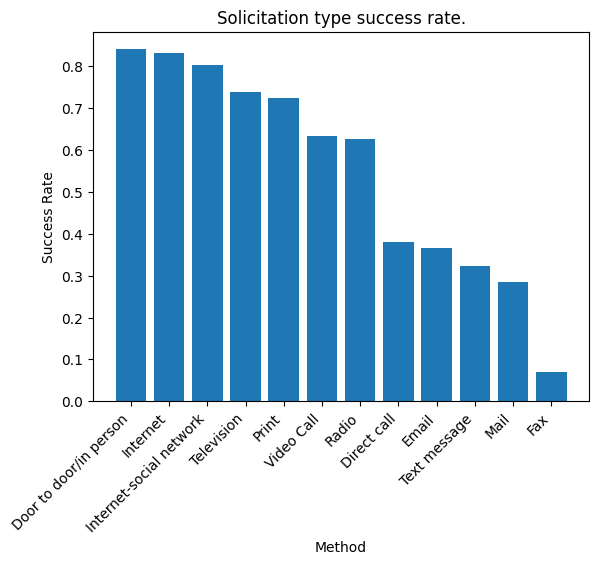

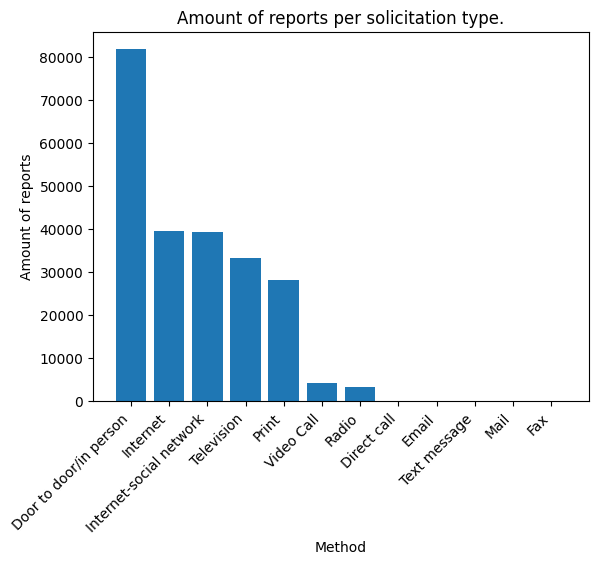

In [26]:
# Question 1 - Which solicitation method has the highest success rate?

data = []
amountData = []

total = df.groupby("solicitation_method").size()
victims = df[df["complaint_type"] == "Victim"].groupby("solicitation_method").size()

for i in total.index:
    percent = (victims[i] / total[i])
    amount = total[i]
    l = [i,percent]
    l2 = [i,amount]
    data.append(l)
    amountData.append(l2)

result = pa.DataFrame(data, columns=["solicitation_method","success_rate"])
result = result[~result["solicitation_method"].isin(["Other/unknown", "Not Available"])]
result = result.sort_values("success_rate",ascending=False)

result2 = pa.DataFrame(amountData, columns=["solicitation_method","amount_of_reports"])
result2 = result2[~result2["solicitation_method"].isin(["Other/unknown", "Not Available"])]
result2 = result2.sort_values("amount_of_reports",ascending=False)

index = result["solicitation_method"].to_numpy()
values = result["success_rate"].to_numpy()
sizeValues = result2["amount_of_reports"].to_numpy()

plt.bar(index,values)
plt.xlabel("Method")
plt.xticks(rotation=45,ha='right')
plt.ylabel("Success Rate")
plt.title("Solicitation type success rate.")
plt.show()


plt.bar(index,sizeValues)
plt.xlabel("Method")
plt.xticks(rotation=45,ha='right')
plt.ylabel("Amount of reports")
plt.title("Amount of reports per solicitation type.")
plt.show()


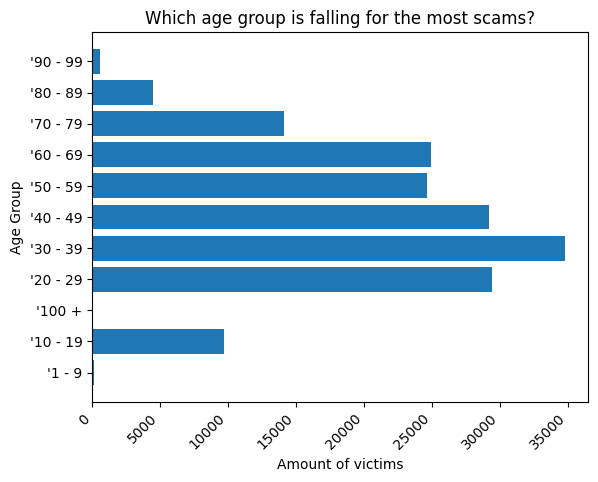

In [25]:
# Question 2 - Which age range fell for the most scams?

victims = df[df["complaint_type"] == "Victim"].groupby("victim_age_range").size()

victims = victims.drop([
    "'Not Available / non disponible",
    "'Deceased / Décédé",
    "'Business / Entreprise"
], errors="ignore")

index = victims.index
index = index.to_numpy()
values = victims.to_numpy()

plt.barh(index,values)
plt.ylabel("Age Group")
plt.xticks(rotation=45,ha='right')
plt.xlabel("Amount of victims")
plt.title("Which age group is falling for the most scams?")
plt.show()


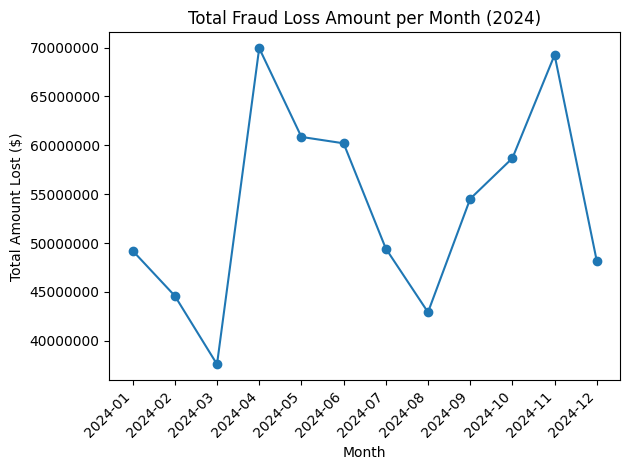

In [ ]:
# Question 3 - How much money was lost per month in 2024?

df["date"] = pa.to_datetime(df["date_received"], errors="coerce")
df["dollar_loss"] = pa.to_numeric(df["dollar_loss"], errors="coerce")
df["year"] = df["date"].dt.year
df_year = df[df["year"] == 2024].copy()

df_year["year_month"] = df_year["date"].dt.to_period("M")
monthly_loss = df_year.groupby("year_month")["dollar_loss"].sum().sort_index()

plt.plot(monthly_loss.index.astype(str), monthly_loss.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Total Amount Lost ($)")
plt.title("Total Fraud Loss Amount per Month (2024)")
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

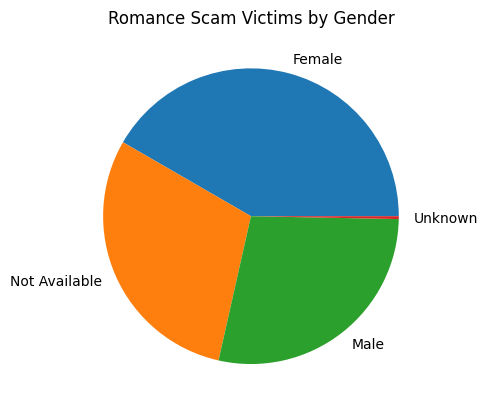

In [ ]:
# Question 4 - Which gender fell for the most romance scams?

romance = df[df["fraud_category"] == "Romance Scam"]
romance = romance[~romance["gender"].isin(["Prefer not to say", "Other"])]
gender_counts = romance["gender"].value_counts()


gender_counts.plot(kind="pie")
plt.title("Romance Scam Victims by Gender")
plt.ylabel("")
plt.show()

Text(0.5, 1.0, 'Average Fraud Loss Amount by Age Group')

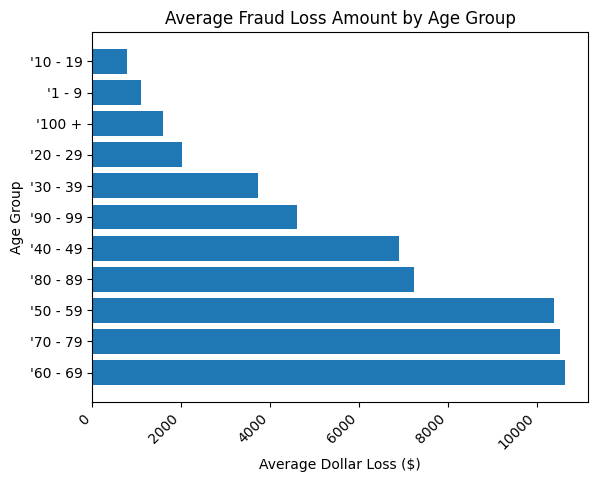

In [3]:
# Question 5 - How much money do age groups lose on average

copy = df.copy()

copy["dollar_loss"] = pa.to_numeric(df["dollar_loss"], errors="coerce")
avg_loss_by_age = df.groupby("victim_age_range")["dollar_loss"].mean().sort_values(ascending=False)
avg_loss_by_age = avg_loss_by_age.drop([
    "'Not Available / non disponible",
    "'Deceased / Décédé",
    "'Business / Entreprise"
], errors="ignore")


plt.barh(avg_loss_by_age.index, avg_loss_by_age.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Age Group")
plt.xlabel("Average Dollar Loss ($)")
plt.title("Average Fraud Loss Amount by Age Group")

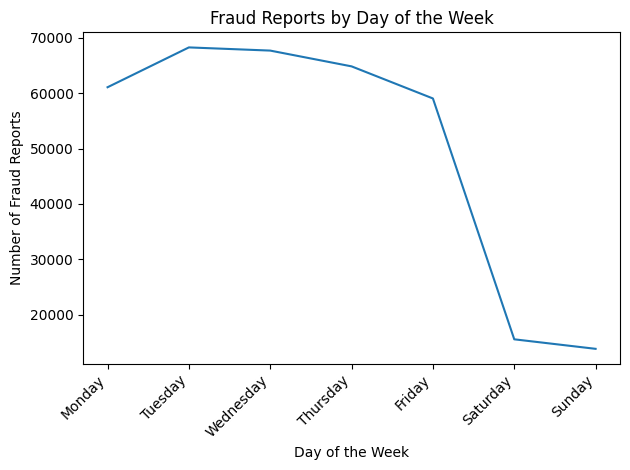

In [ ]:
# Question 6 - Which day of the week gets the most reports?

df["date"] = pa.to_datetime(df["date_received"], errors="coerce")

df["weekday"] = df["date"].dt.day_name()
weekday_counts = df["weekday"].value_counts()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_counts = weekday_counts.reindex(order)

plt.plot(weekday_counts.index, weekday_counts.values)
plt.xlabel("Day of the Week")
plt.ylabel("Number of Fraud Reports")
plt.title("Fraud Reports by Day of the Week")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The mean dollar loss is: $68908211.38 dollars.
The median dollar loss is: $1946897.87 dollars.
The standard deviation is: 223269148.39.


Text(0.5, 1.0, 'Total Dollar Loss by Fraud Type')

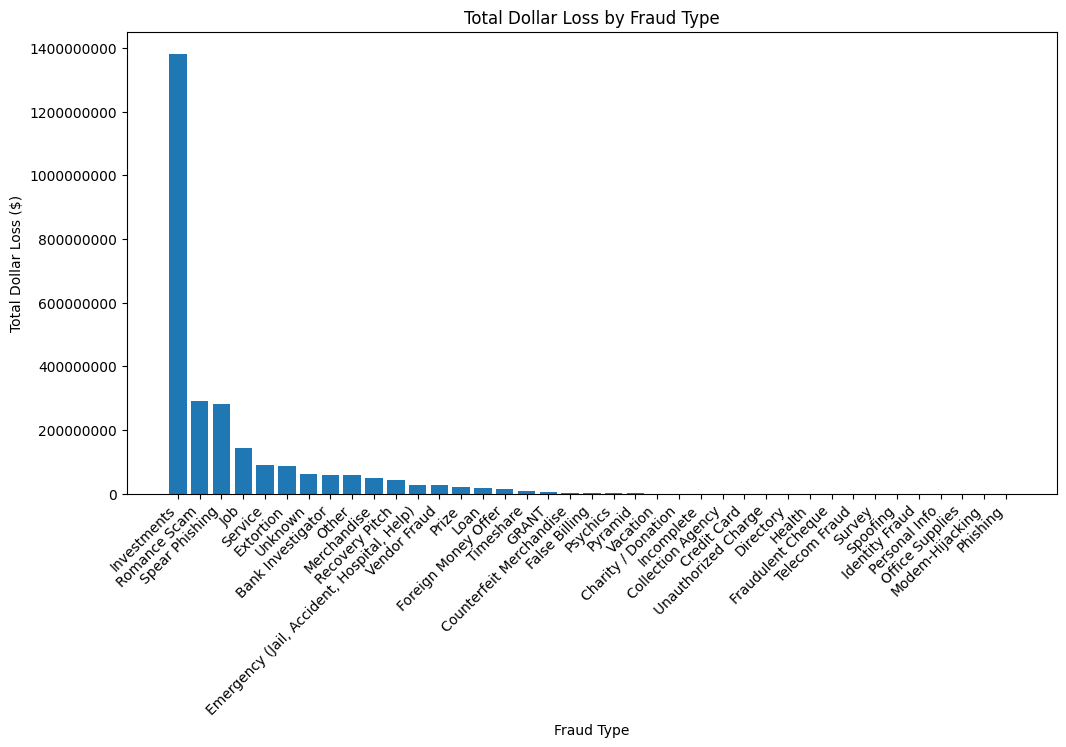

In [10]:
# Question 7 - How much money is lost per fraud type?

df["dollar_loss"] = pa.to_numeric(df["dollar_loss"], errors="coerce")
total_loss_by_type = df.groupby("fraud_category")["dollar_loss"].sum()
total_loss_by_type = total_loss_by_type.sort_values(ascending=False)

mean = np.mean(total_loss_by_type.to_numpy())
sd = np.std(total_loss_by_type.to_numpy())
median = np.median(total_loss_by_type.to_numpy())
print(f"The mean dollar loss is: ${mean:.2f} dollars.")
print(f"The median dollar loss is: ${median:.2f} dollars.")
print(f"The standard deviation is: {sd:.2f}.")

plt.figure(figsize=(12, 6))
plt.bar(total_loss_by_type.index, total_loss_by_type.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Fraud Type")
plt.ylabel("Total Dollar Loss ($)")
plt.ticklabel_format(style='plain', axis='y')
plt.title("Total Dollar Loss by Fraud Type")



The mean is: 1345.45.
The median is: 401.00.
The standard deviation is: 1850.12.


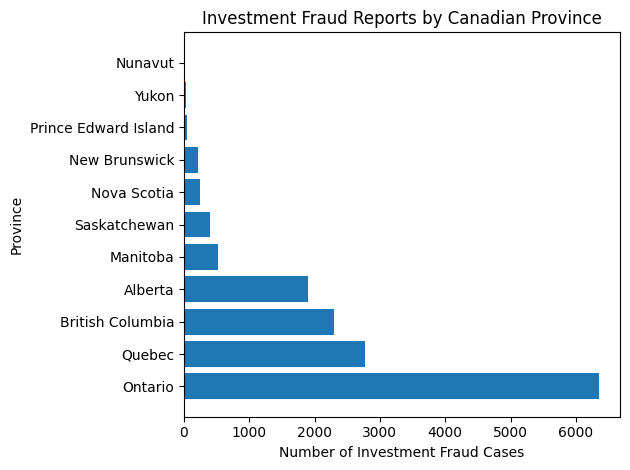

In [14]:
# Question 8 - Which province falls for the most investment scams?

canadian_provinces = [
    "Ontario", "Quebec", "British Columbia", "Alberta",
    "Manitoba", "Saskatchewan", "Nova Scotia", "New Brunswick",
    "Prince Edward Island", "Newfoundland and Labrador",
    "Northwest Territories", "Yukon", "Nunavut"
]

df_canada = df[df["province_state"].isin(canadian_provinces)].copy()

investment_canada = df_canada[df_canada["fraud_category"] == "Investments"]
province_counts = investment_canada["province_state"].value_counts()

mean = np.mean(province_counts.to_numpy())
sd = np.std(province_counts.to_numpy())
median = np.median(province_counts.to_numpy())
print(f"The mean is: {mean:.2f}.")
print(f"The median is: {median:.2f}.")
print(f"The standard deviation is: {sd:.2f}.")

plt.barh(province_counts.index, province_counts.values)
plt.xlabel("Number of Investment Fraud Cases")
plt.ylabel("Province")
plt.title("Investment Fraud Reports by Canadian Province")
plt.tight_layout()
plt.show()



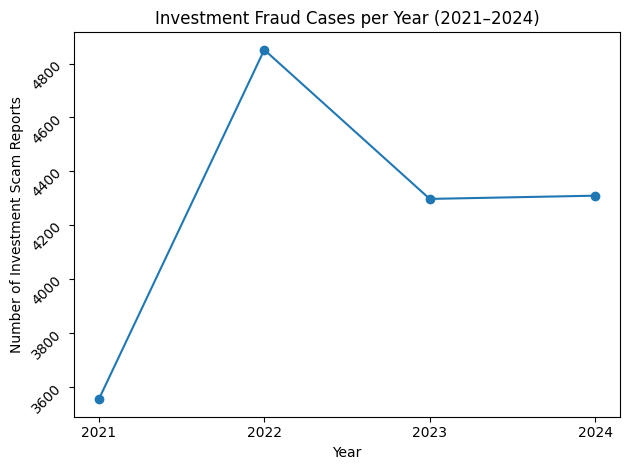

In [ ]:
# Question 9 - What is the rise of Investment Fraud cases from 2021-2024

df["date"] = pa.to_datetime(df["date_received"], errors="coerce")
df["year"] = df["date"].dt.year

inv = df[
    (df["fraud_category"] == "Investments") &
    (df["year"].between(2021, 2024))
]

year_counts = inv.groupby("year").size()

plt.plot(year_counts.index, year_counts.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Investment Scam Reports")
plt.yticks(rotation=45,ha='right')
plt.title("Investment Fraud Cases per Year (2021–2024)")
plt.xticks(year_counts.index)  # ensures correct year labels
plt.tight_layout()
plt.show()

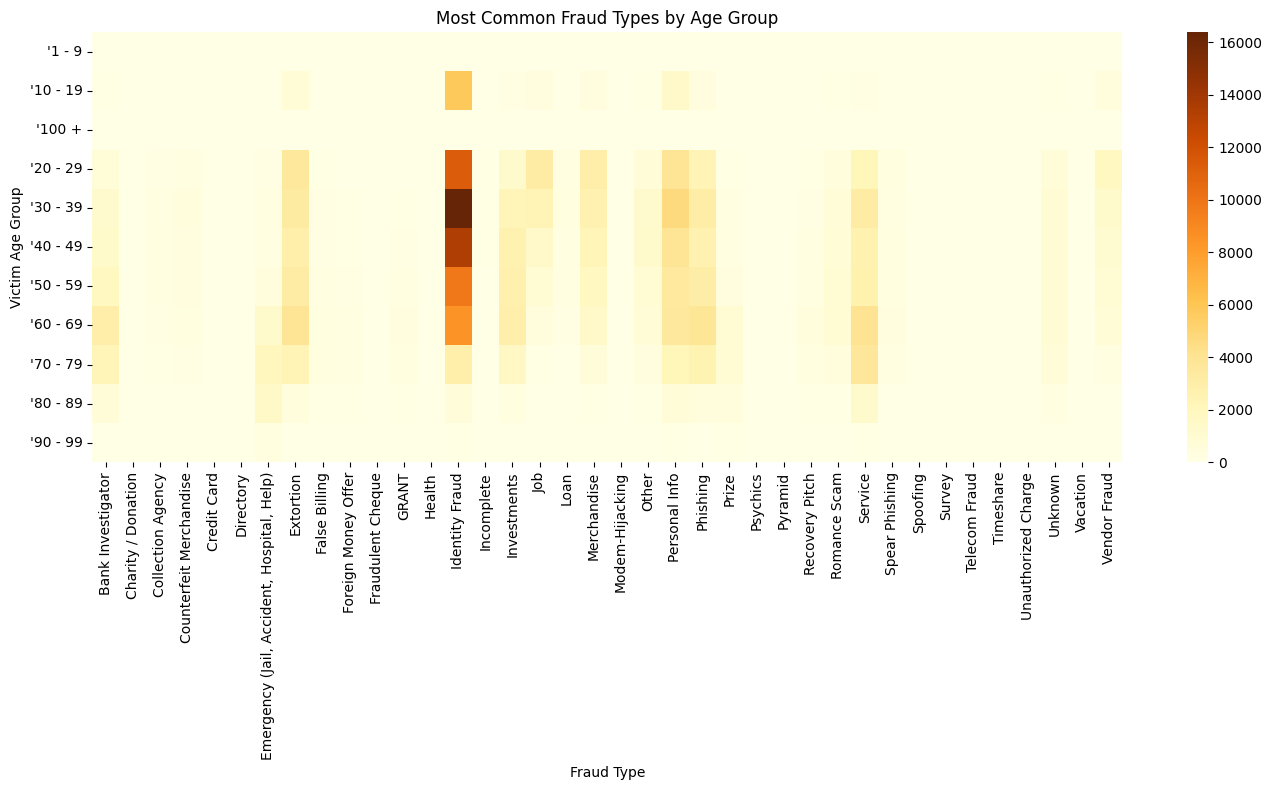

In [33]:
# Question 10 - What are the most common fraud types by Age Group?

df["victim_age_range"] = df["victim_age_range"].astype(str)
victims = df[~df["victim_age_range"].isin(["'Not Available / non disponible",
    "'Deceased / Décédé",
    "'Business / Entreprise"])]


pivot = victims.pivot_table(
    index="victim_age_range",
    columns="fraud_category",
    aggfunc="size",
    fill_value=0
)


plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap="YlOrBr", annot=False)
plt.title("Most Common Fraud Types by Age Group")
plt.xlabel("Fraud Type")
plt.ylabel("Victim Age Group")
plt.yticks(rotation=0,ha='right')
plt.tight_layout()
plt.show()